## Task 1: Tensor Manipulations & Reshaping

In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [2]:
import tensorflow as tf
tensor = tf.random.uniform(shape=(4, 6), minval=0, maxval=10, dtype=tf.float32)
print("Original tensor (4, 6):\n", tensor.numpy())
print("\n--- Before reshaping/transposing ---")
print("Rank:", tf.rank(tensor).numpy())      # number of dimensions
print("Shape:", tensor.shape)                # (4, 6)
reshaped_tensor = tf.reshape(tensor, (2, 3, 4))
transposed_tensor = tf.transpose(reshaped_tensor, perm=[1, 0, 2])

print("\n--- After reshaping to (2, 3, 4) ---")
print("Rank:", tf.rank(reshaped_tensor).numpy())
print("Shape:", reshaped_tensor.shape)

print("\n--- After transposing to (3, 2, 4) ---")
print("Rank:", tf.rank(transposed_tensor).numpy())
print("Shape:", transposed_tensor.shape)
small_tensor = tf.random.uniform(shape=(1, 4), minval=0, maxval=10, dtype=tf.float32)
print("\nSmall tensor (1, 4):\n", small_tensor.numpy())

broadcast_sum = transposed_tensor + small_tensor

print("\nResult of broadcasting add -> shape:", broadcast_sum.shape)
print(broadcast_sum.numpy())


Original tensor (4, 6):
 [[6.160179  3.9125085 3.4909964 3.423704  4.0394735 0.6459093]
 [8.266228  4.1998506 4.2459545 2.3502147 5.052208  3.4907234]
 [4.9769187 9.68038   5.791048  2.807902  6.1596622 9.689035 ]
 [6.468402  9.209799  5.075575  1.9191945 2.575612  7.5058737]]

--- Before reshaping/transposing ---
Rank: 2
Shape: (4, 6)

--- After reshaping to (2, 3, 4) ---
Rank: 3
Shape: (2, 3, 4)

--- After transposing to (3, 2, 4) ---
Rank: 3
Shape: (3, 2, 4)

Small tensor (1, 4):
 [[5.1750445 5.690968  3.757913  4.793806 ]]

Result of broadcasting add -> shape: (3, 2, 4)
[[[11.335224   9.603477   7.2489095  8.21751  ]
  [10.151963  15.371347   9.548962   7.6017084]]

 [[ 9.214518   6.3368773 12.024141   8.993656 ]
  [11.334707  15.380003  10.226315  14.003605 ]]

 [[ 9.421      8.0411825  8.810122   8.28453  ]
  [10.25062    7.6101627  6.333525  12.29968  ]]]


## Task 2: Loss Functions & Hyperparameter Tuning

In [1]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is building the font cache; this may take a moment.


Matplotlib is working!


Original predictions:
MSE Loss: 0.04888889
Categorical Cross-Entropy Loss: 0.36354804

Better predictions (closer to y_true):
MSE Loss: 0.012222222
Categorical Cross-Entropy Loss: 0.16367431

Worse predictions (further from y_true):
MSE Loss: 0.20444445
Categorical Cross-Entropy Loss: 1.0121847


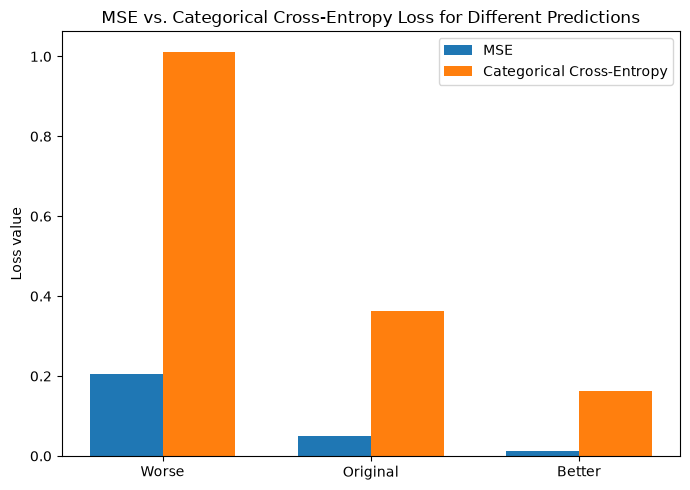

Bar chart saved as 'mse_vs_cce_loss.png'


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
y_true = tf.constant([[0, 1, 0],
                       [1, 0, 0],
                       [0, 0, 1]], dtype=tf.float32)

# y_pred: predicted probabilities from a model (rows sum to ~1)
y_pred = tf.constant([[0.1, 0.8, 0.1],
                       [0.7, 0.2, 0.1],
                       [0.2, 0.2, 0.6]], dtype=tf.float32)
mse = tf.keras.losses.MeanSquaredError()
cce = tf.keras.losses.CategoricalCrossentropy()

mse_loss = mse(y_true, y_pred).numpy()
cce_loss = cce(y_true, y_pred).numpy()

print("Original predictions:")
print("MSE Loss:", mse_loss)
print("Categorical Cross-Entropy Loss:", cce_loss)
y_pred_better = tf.constant([[0.05, 0.9, 0.05],
                              [0.85, 0.1, 0.05],
                              [0.1, 0.1, 0.8]], dtype=tf.float32)

# Make the predictions slightly "worse" (further from the true labels)
y_pred_worse = tf.constant([[0.3, 0.4, 0.3],
                             [0.4, 0.4, 0.2],
                             [0.4, 0.3, 0.3]], dtype=tf.float32)

mse_better = mse(y_true, y_pred_better).numpy()
cce_better = cce(y_true, y_pred_better).numpy()

mse_worse = mse(y_true, y_pred_worse).numpy()
cce_worse = cce(y_true, y_pred_worse).numpy()

print("\nBetter predictions (closer to y_true):")
print("MSE Loss:", mse_better)
print("Categorical Cross-Entropy Loss:", cce_better)

print("\nWorse predictions (further from y_true):")
print("MSE Loss:", mse_worse)
print("Categorical Cross-Entropy Loss:", cce_worse)


labels = ["Worse", "Original", "Better"]
mse_values = [mse_worse, mse_loss, mse_better]
cce_values = [cce_worse, cce_loss, cce_better]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar([i - width / 2 for i in x], mse_values, width=width, label="MSE")
plt.bar([i + width / 2 for i in x], cce_values, width=width, label="Categorical Cross-Entropy")
plt.xticks(list(x), labels)
plt.ylabel("Loss value")
plt.title("MSE vs. Categorical Cross-Entropy Loss for Different Predictions")
plt.legend()
plt.tight_layout()
plt.savefig("mse_vs_cce_loss.png")
plt.show()

print("Bar chart saved as 'mse_vs_cce_loss.png'")


## Task 3: Train a Model with Different Optimizers

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10


/opt/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 - 2s - 1ms/step - accuracy: 0.9151 - loss: 0.2911 - val_accuracy: 0.9594 - val_loss: 0.1360
Epoch 2/10
1875/1875 - 1s - 792us/step - accuracy: 0.9584 - loss: 0.1413 - val_accuracy: 0.9689 - val_loss: 0.0970
Epoch 3/10
1875/1875 - 2s - 812us/step - accuracy: 0.9666 - loss: 0.1079 - val_accuracy: 0.9763 - val_loss: 0.0785
Epoch 4/10
1875/1875 - 2s - 815us/step - accuracy: 0.9726 - loss: 0.0876 - val_accuracy: 0.9755 - val_loss: 0.0805
Epoch 5/10
1875/1875 - 2s - 816us/step - accuracy: 0.9761 - loss: 0.0746 - val_accuracy: 0.9773 - val_loss: 0.0740
Epoch 6/10
1875/1875 - 2s - 810us/step - accuracy: 0.9792 - loss: 0.0664 - val_accuracy: 0.9776 - val_loss: 0.0748
Epoch 7/10
1875/1875 - 2s - 844us/step - accuracy: 0.9815 - loss: 0.0583 - val_accuracy: 0.9791 - val_loss: 0.0721
Epoch 8/10
1875/1875 - 1s - 796us/step - accuracy: 0.9830 - loss: 0.0518 - val_accuracy: 0.9795 - val_loss: 0.0691
Epoch 9/10
1875/1875 - 2s - 801us/step - accuracy: 0.9840 - loss: 0.0489 - val_accuracy: 0.97

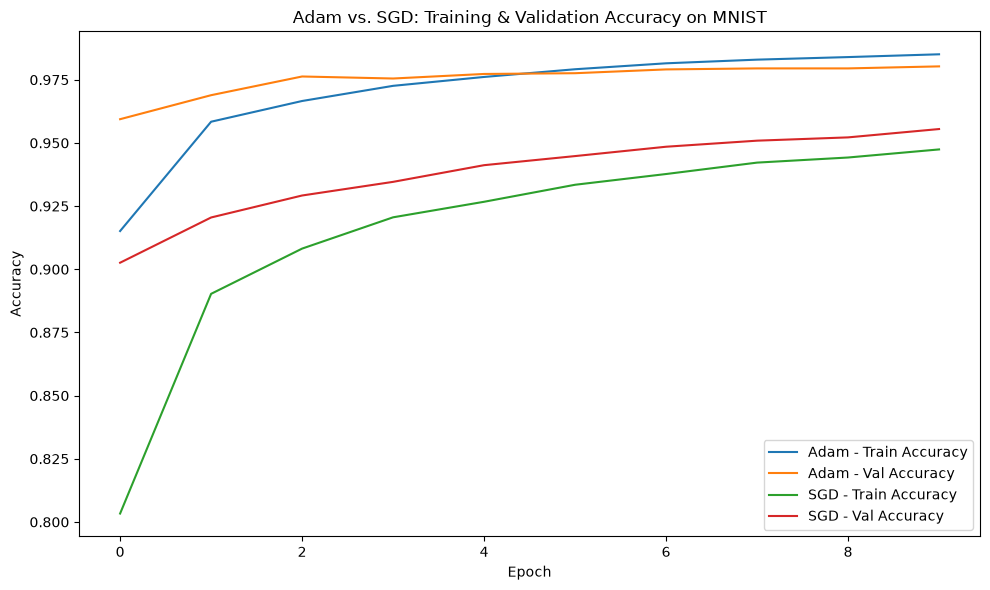

Final Adam val accuracy: 0.9803000092506409
Final SGD val accuracy: 0.9555000066757202


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


def build_model():
    """Builds a simple fully-connected neural network for MNIST digit classification."""
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    return model
EPOCHS = 10
BATCH_SIZE = 32

# --- Model 1: Adam optimizer ---
model_adam = build_model()
model_adam.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_adam = model_adam.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)

# --- Model 2: SGD optimizer ---
model_sgd = build_model()
model_sgd.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_sgd = model_sgd.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
)
plt.figure(figsize=(10, 6))
plt.plot(history_adam.history["accuracy"], label="Adam - Train Accuracy")
plt.plot(history_adam.history["val_accuracy"], label="Adam - Val Accuracy")
plt.plot(history_sgd.history["accuracy"], label="SGD - Train Accuracy")
plt.plot(history_sgd.history["val_accuracy"], label="SGD - Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam vs. SGD: Training & Validation Accuracy on MNIST")
plt.legend()
plt.tight_layout()
plt.savefig("adam_vs_sgd_accuracy.png")
plt.show()

print("Final Adam val accuracy:", history_adam.history["val_accuracy"][-1])
print("Final SGD val accuracy:", history_sgd.history["val_accuracy"][-1])


## Task 4: Train a Neural Network and Log to TensorBoard

In [4]:
import datetime
import tensorflow as tf

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,  # also logs weight/activation histograms each epoch
)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    callbacks=[tensorboard_callback],
    verbose=2,
)

print(f"\nTraining complete. Logs written to: {log_dir}")
print("Launch TensorBoard with:  tensorboard --logdir logs/fit")


Epoch 1/5
1875/1875 - 2s - 1ms/step - accuracy: 0.9136 - loss: 0.2973 - val_accuracy: 0.9601 - val_loss: 0.1380
Epoch 2/5
1875/1875 - 2s - 936us/step - accuracy: 0.9579 - loss: 0.1414 - val_accuracy: 0.9708 - val_loss: 0.0971
Epoch 3/5
1875/1875 - 2s - 915us/step - accuracy: 0.9682 - loss: 0.1066 - val_accuracy: 0.9747 - val_loss: 0.0812
Epoch 4/5
1875/1875 - 2s - 907us/step - accuracy: 0.9727 - loss: 0.0874 - val_accuracy: 0.9732 - val_loss: 0.0847
Epoch 5/5
1875/1875 - 2s - 906us/step - accuracy: 0.9760 - loss: 0.0755 - val_accuracy: 0.9776 - val_loss: 0.0757

Training complete. Logs written to: logs/fit/20260909-135258
Launch TensorBoard with:  tensorboard --logdir logs/fit
